# How did currents change at Cape Henry on 6 May 2025?

Read one UTC day of current speed and direction at Cape Henry LB 2CH (`cb0102`), **bin 4**. The [manifest](dataset.yaml) selects observed currents, with metric speeds in **cm/s**. Keep the raw CSV and its provenance while plotting locally with pandas and matplotlib.

CO-OPS currents support is available since v0.24.0. See the [run instructions](https://usdata.dev/studies/#run) and [provider guide](https://docs.usdata.dev/providers/noaa-coops-currents/).

In [1]:
from pathlib import Path
from tempfile import TemporaryDirectory

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import pandas as pd

from usdata import pull, verify

manifest = Path("dataset.yaml")
result = pull(manifest)
item = result.one("currents")
raw = item.open(dtype={"Date Time": "string"})
print(f"Fetched {len(raw)} observations; locked {len(result.lockfile.assets)} asset.")
print("Source:", item.asset.href)
print("SHA256:", item.provenance.checksum)
raw.head()

Fetched 239 observations; locked 1 asset.
Source: https://api.tidesandcurrents.noaa.gov/api/prod/datagetter?station=cb0102&product=currents&begin_date=20250506+00%3A00&end_date=20250506+23%3A59&bin=4&units=metric&time_zone=gmt&format=csv&application=usdata
SHA256: sha256:418f89fee24651e1267b67bd3c1eadd8cbb85f59652417577b16a54e31538f08


,Date Time,Speed,Direction,Bin
0,2025-05-06 00:02,17.3,285,4
1,2025-05-06 00:08,18.5,286,4
2,2025-05-06 00:14,15.9,280,4
3,2025-05-06 00:20,13.3,301,4
4,2025-05-06 00:26,15.1,282,4


## Keep the bin and depth distinct

The CSV includes `Bin`, but no depth. [NOAA's metadata](https://api.tidesandcurrents.noaa.gov/mdapi/prod/webapi/stations/cb0102/bins.json) retrieved on **2026-09-22** reports bin 4 at **6.52 m** and a downward-looking instrument. The [deployment record](https://api.tidesandcurrents.noaa.gov/mdapi/prod/webapi/stations/cb0102/deployments.json) lists the active deployment from **2025-01-27**, before this example day.

The exact responses, URLs, and SHA256 hashes are preserved in the [dated metadata snapshot](https://github.com/jakeryderv/usdata/blob/main/examples/datasets/noaa-coops-currents/metadata.json). This is context from the current metadata service, not independent verification of historical depth. Bin depths can change across deployments, and some instruments look sideways. We therefore label this analysis by **station and bin**, not an assumed fixed depth.

The Data API was requested in UTC. Its unzoned timestamp strings are interpreted as UTC, without a daylight-saving conversion. Header spaces are stripped only in the local analysis table; cached source bytes stay unchanged.

In [2]:
observations = raw.rename(columns=lambda name: name.strip()).copy()
observations["time"] = pd.to_datetime(observations["Date Time"], format="%Y-%m-%d %H:%M", utc=True)
bins = pd.to_numeric(observations["Bin"], errors="raise")
assert bins.eq(4).all(), "Unexpected bin in the returned data."
assert not observations["time"].duplicated().any(), "Duplicate times need investigation."
observations["speed_cm_s"] = pd.to_numeric(observations["Speed"], errors="coerce")
observations["direction_deg"] = pd.to_numeric(observations["Direction"], errors="coerce")
# Blank or invalid measurements are counted and masked, never interpreted as zero.
bad_speed = observations["speed_cm_s"].isna() | ~observations["speed_cm_s"].between(
    0, float("inf"), inclusive="left"
)
bad_direction = observations["direction_deg"].isna() | ~observations["direction_deg"].between(
    0, 360
)
observations.loc[bad_speed, "speed_cm_s"] = float("nan")
observations.loc[bad_direction, "direction_deg"] = float("nan")
observations = observations.sort_values("time").set_index("time")
start = pd.Timestamp("2025-05-06", tz="UTC")
stop = start + pd.Timedelta(days=1)
assert ((observations.index >= start) & (observations.index < stop)).all()
# Infer the sampling phase, then require every observation to share that six-minute grid.
step = pd.Timedelta(minutes=6)
phase = (observations.index[0] - start) % step
assert (((observations.index - start) % step) == phase).all(), (
    "Mixed sampling phases need investigation."
)
expected = pd.date_range(start + phase, stop, freq=step, inclusive="left")
missing = expected.difference(observations.index)
series = observations[["speed_cm_s", "direction_deg"]].reindex(expected)
print(f"Returned observations: {len(observations)}; expected six-minute slots: {len(expected)}")
print(
    f"Missing timestamps: {len(missing)}; invalid/blank speed: {bad_speed.sum()}; "
    f"invalid/blank direction: {bad_direction.sum()}"
)
print("Missing UTC times:", ", ".join(time.strftime("%H:%M") for time in missing) or "none")
print("Duplicate timestamps: 0 (checked before plotting)")
observations[["speed_cm_s", "direction_deg"]].head()

Returned observations: 239; expected six-minute slots: 240
Missing timestamps: 1; invalid/blank speed: 0; invalid/blank direction: 0
Missing UTC times: 19:32
Duplicate timestamps: 0 (checked before plotting)


,speed_cm_s,direction_deg
time,,
2025-05-06 00:02:00+00:00,17.3,285.0
2025-05-06 00:08:00+00:00,18.5,286.0
2025-05-06 00:14:00+00:00,15.9,280.0
2025-05-06 00:20:00+00:00,13.3,301.0
2025-05-06 00:26:00+00:00,15.1,282.0


## Speed and direction through the day

The upper plot leaves missing samples as gaps. The lower plot uses separate points: direction is circular, so a line across 359° and 1° would imply a large swing. NOAA's [glossary](https://tidesandcurrents.noaa.gov/glossary.html) defines current direction as the direction **toward which** the water flows. Here we show its reported angle in degrees without calculating flood/ebb classifications or averaging angles.

Metric speed means **centimeters per second**, not meters per second. English-unit probe results agreed after converting knots to cm/s, within rounding. This basic response has no verification-quality field, and the absence of one does not establish verified quality.

Observed speed range: 1.6 to 85.8 cm/s
Largest observed speed at 14:56 UTC (first occurrence if tied)


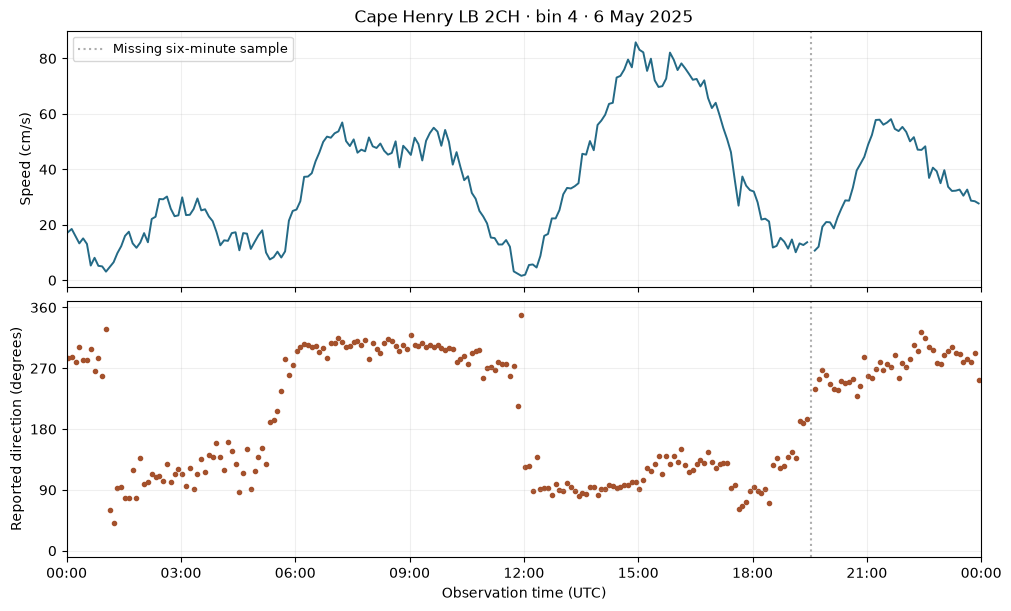

In [3]:
speed = series["speed_cm_s"].dropna()
assert not speed.empty, "No usable speeds to summarize."
print(f"Observed speed range: {speed.min():.1f} to {speed.max():.1f} cm/s")
print(f"Largest observed speed at {speed.idxmax():%H:%M} UTC (first occurrence if tied)")

fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True, constrained_layout=True)
axes[0].plot(series.index, series["speed_cm_s"], color="#246a86", linewidth=1.4)
axes[0].set_ylabel("Speed (cm/s)")
axes[0].set_title("Cape Henry LB 2CH · bin 4 · 6 May 2025")
axes[1].scatter(series.index, series["direction_deg"], s=9, color="#a4512c")
axes[1].set_ylabel("Reported direction (degrees)")
axes[1].set_yticks([0, 90, 180, 270, 360])
axes[1].set_ylim(-10, 370)
axes[1].set_xlabel("Observation time (UTC)")
axes[1].xaxis.set_major_locator(mdates.HourLocator(byhour=range(0, 24, 3)))
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%H:%M", tz=start.tzinfo))
axes[1].set_xlim(start, stop)
for axis in axes:
    for index, time in enumerate(missing):
        axis.axvline(
            time,
            color="#777777",
            linestyle=":",
            alpha=0.6,
            label="Missing six-minute sample" if index == 0 else None,
        )
    axis.grid(alpha=0.2)
if len(missing):
    axes[0].legend(loc="upper left", fontsize=9)
plt.show()

## Restore the same bytes into an empty cache

The manifest produces a lockfile containing the source URL and checksum. Verify it, then restore that same lockfile into a fresh cache and compare the raw bytes. This proves reproducibility at execution time; CO-OPS may revise query responses later. Keep the manifest, lockfile, cached CSV, and dated metadata with the analysis.

In [4]:
assert verify(manifest) == []
with TemporaryDirectory(prefix="usdata-currents-restore-") as fresh:
    restored = pull(manifest, root=fresh)
    copy = restored.one("currents")
    assert restored.from_lockfile and not copy.from_cache
    assert restored.lockfile == result.lockfile
    assert verify(manifest, root=fresh) == []
    assert copy.path.read_bytes() == item.path.read_bytes()
    print("Restored SHA256:", copy.provenance.checksum)
print("Pinned currents restored byte-for-byte into an empty cache and passed verification.")

Restored SHA256: sha256:418f89fee24651e1267b67bd3c1eadd8cbb85f59652417577b16a54e31538f08
Pinned currents restored byte-for-byte into an empty cache and passed verification.


## What was awkward

- Bin number does not encode a permanent depth, so the example keeps dated metadata and qualifies historical applicability.
- The CSV does not label speed units; the manifest and source URL do.
- Six-minute records here are offset by two minutes from the hour, with a missing slot; the analysis validates the grid before counting gaps.
- Direction is circular and the basic response has no quality flag, so unconnected angle observations are shown without a quality claim.
- NOAA's interval documentation is contradictory: the live `interval=h` probe returned unchanged six-minute data. This example requests the native observations only.